In [ ]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import networkx as nx
import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as colors
from github_helper import from_github

# Structure of the network
In understanding the structure of our network, we first investigate the effects of thresholding, and then the implications for the temporality of the network.

## Degree Distribution
We first wish to compare the degree distribution of our network to known degree distributions.
In order to do this we build the network for "klima_miljø" in period 71 and compute it's degree distributions under different thresholds. We then fit Power-Law, Log-Normal, Exponential and Poisson distributions to the degree distributions, and analyze which, if any, distribution best fits the distribution of the network.

In [ ]:
def make_specific_graph(topic_df, period, threshold=0.7):
    """Builds a graph for a single period at a given threshold from a preloaded topic_df."""
    specific_df = topic_df[topic_df['Period'] == period]
    thresh_df = specific_df[specific_df['weight'] >= threshold]
    if thresh_df.empty:
        return nx.Graph()  # empty
    G = nx.from_pandas_edgelist(thresh_df, source='source', target='target', edge_attr='weight')
    return G

def degrees_across_periods(topic="general", agg_level="politician", period_level="Period",
                           threshold=0.7, periods=None):
    """
    Returns a long DataFrame with columns: ['Period','node','degree']
    One row per (node, period) when the node appears in the thresholded graph.
    """
    # Load once
    topic_df = pd.read_csv(from_github(f"/edges/{agg_level}/{period_level}/{agg_level}_edges_{topic}_by_{period_level}.csv"))

    # Pick periods to include
    if periods is None:
        periods = sorted(topic_df[period_level].unique().tolist())
    else:
        periods = [p for p in periods if p in set(topic_df[period_level].unique())]

    rows = []
    for p in periods:
        G = make_specific_graph(topic_df.rename(columns={period_level: 'Period'}), period=p, threshold=threshold)
        if len(G) == 0:
            continue
        for node, deg in G.degree():
            rows.append((p, node, deg))

    df_deg = pd.DataFrame(rows, columns=['Period', 'node', 'degree'])
    return df_deg

In [43]:
def fit_and_plot_logbinned_multi(
    df_deg,
    periods=(66, 67, 68, 69, 70, 71),
    ax=None,
    num_bins=20,
    period_labels=None,
    threshold=0.7,
    topic="general"
):
    """
    Overlays log-binned degree histograms for each period (transparent lines),
    adds opaque 'average across periods' and 'sum across periods' curves,
    and fits/plots model curves using the combined data (sum across periods).
    Returns the Matplotlib axis (ax) for further composition.
    """

    # --- Collect per-period degree data ---
    per_period = {}
    for p in periods:
        s = df_deg.loc[df_deg['Period'] == p, 'degree'].astype(int)
        s = s[s > 0]
        if s.size > 0:
            per_period[p] = s.values

    if not per_period:
        print("No degree data for the requested periods.")
        return ax

    combined = np.concatenate(list(per_period.values()))
    combined = combined[combined > 0]
    n = combined.size

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # --- Log-binning setup (shared across all periods) ---
    dmin = max(1, int(combined.min()))
    dmax = int(combined.max())
    if dmin == dmax:
        dmin = max(1, dmin - 1)
        dmax = dmax + 1
    bins = np.logspace(np.log10(dmin), np.log10(dmax), num_bins)
    bin_centers = np.sqrt(bins[:-1] * bins[1:])

    # --- Prepare colors ---
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key().get('color', None)
    if color_cycle is None:
        color_cycle = ['C0','C1','C2','C3','C4','C5','C6','C7','C8','C9']

    # --- Plot each period’s line (more transparent) ---
    period_list = sorted(per_period.keys())
    all_counts = []

    for i, p in enumerate(period_list):
        data_p = per_period[p]
        counts_p, _ = np.histogram(data_p, bins=bins)
        all_counts.append(counts_p)
        pos = counts_p > 0
        label = period_labels.get(p, f"Period {p}") if period_labels else f"Period {p}"

        ax.plot(
            bin_centers[pos],
            counts_p[pos],
            #marker='o',
            markersize=3,
            linewidth=1.2,
            alpha=0.4,  # ↑ increased transparency for individual periods
            label=label,
            color=color_cycle[i % len(color_cycle)]
        )

    # --- Aggregate curves: Average & Sum across periods ---
    stacked = np.stack(all_counts)                  # shape: (num_periods, num_bins-1)
    avg_counts = stacked.mean(axis=0)
    sum_counts = stacked.sum(axis=0)                # this matches the histogram of 'combined' with same bins

    # # Average across periods (opaque, distinct style)
    # pos_avg = avg_counts > 0
    # ax.plot(
    #     bin_centers[pos_avg],
    #     avg_counts[pos_avg],
    #     marker='o',
    #     markersize=4,
    #     linewidth=2.0,
    #     alpha=1.0,                     # fully opaque
    #     color='dimgray',
    #     label='Average across periods'
    # )

    # Sum across periods (opaque, bolder)
    pos_sum = sum_counts > 0
    ax.plot(
        bin_centers[pos_sum],
        sum_counts[pos_sum],
        marker='o',
        markersize=4,
        linewidth=2.0,
        alpha=1.0,                     # fully opaque
        color='black',
        label='Total across periods'
    )

    # --- Combined data for model fitting (same as "sum across periods") ---
    counts_all, _ = np.histogram(combined, bins=bins)
    pos_all = counts_all > 0
    if not np.any(pos_all):
        ax.text(0.5, 0.5, "Insufficient data for fitting", ha='center', va='center', transform=ax.transAxes)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel('Degree (log)'); ax.set_ylabel('Number of nodes (log)')
        return ax

    empirical_cdf_x = np.sort(combined)
    empirical_cdf_y = np.arange(1, n + 1) / n

    # --- Power-law fit (on combined/sum distribution) ---
    log_x = np.log(bin_centers[pos_all])
    log_y = np.log(counts_all[pos_all])
    coeffs = np.polyfit(log_x, log_y, 1)
    alpha = -coeffs[0]
    intercept = np.exp(coeffs[1])
    powerlaw_y = intercept * bin_centers ** (-alpha)
    xmin = combined.min()
    cdf_powerlaw = 1 - (xmin / empirical_cdf_x) ** (alpha - 1)
    ks_powerlaw = np.max(np.abs(empirical_cdf_y - cdf_powerlaw))

    # --- Log-normal ---
    shape, loc, scale = stats.lognorm.fit(combined, floc=0)
    lognorm_x = np.linspace(1, combined.max(), 200)
    lognorm_pdf = stats.lognorm.pdf(lognorm_x, shape, loc, scale)
    lognorm_y = lognorm_pdf * counts_all.max() / max(lognorm_pdf.max(), 1e-12)
    ks_lognorm = stats.kstest(combined, 'lognorm', args=(shape, loc, scale)).statistic

    # --- Exponential ---
    exp_params = stats.expon.fit(combined)
    exp_x = np.linspace(1, combined.max(), 200)
    exp_pdf = stats.expon.pdf(exp_x, *exp_params)
    exp_y = exp_pdf * counts_all.max() / max(exp_pdf.max(), 1e-12)
    ks_exp = stats.kstest(combined, 'expon', args=exp_params).statistic

    # --- Poisson (truncated at >0) ---
    lam = combined.mean()
    p0 = stats.poisson.pmf(0, mu=lam)
    k_vals = np.arange(1, max(2, combined.max()) + 1)
    pois_pmf = stats.poisson.pmf(k_vals, mu=lam)
    pois_pmf_trunc = pois_pmf / max((1 - p0), 1e-12)
    pois_y = pois_pmf_trunc * counts_all.max() / max(pois_pmf_trunc.max(), 1e-12)
    cdf_po_trunc = (stats.poisson.cdf(empirical_cdf_x, mu=lam) - p0) / max((1 - p0), 1e-12)
    ks_pois = np.max(np.abs(empirical_cdf_y - cdf_po_trunc))

    # --- Model fits (overlayed; fit on "sum/combined") ---
    line_alpha = 0.55
    ax.plot(bin_centers, powerlaw_y, lw=2.0, alpha=line_alpha, color='k',
            label=f'Power-law fit α={alpha:.2f}, KS={ks_powerlaw:.2f}')
    ax.plot(lognorm_x, lognorm_y, lw=1.8, alpha=line_alpha, color='k', linestyle='--',
            label=f'Log-normal KS={ks_lognorm:.2f}')
    ax.plot(exp_x, exp_y, lw=1.8, alpha=line_alpha, color='k', linestyle=':',
            label=f'Exponential KS={ks_exp:.2f}')
    ax.plot(k_vals, pois_y, lw=1.8, alpha=line_alpha, color='k', linestyle='-.',
            label=f'Poisson KS={ks_pois:.2f}')

    # --- Formatting ---
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree (log)')
    ax.set_ylabel('Number of nodes (log)')
    ax.legend(fontsize=8, ncol=2)
    ax.set_ylim(bottom=0.8, top=1000)
    ax.set_xlim(left=5)
    ax.set_title(f'Threshold = {threshold:.0%}, Topic = {topic}')

    return ax

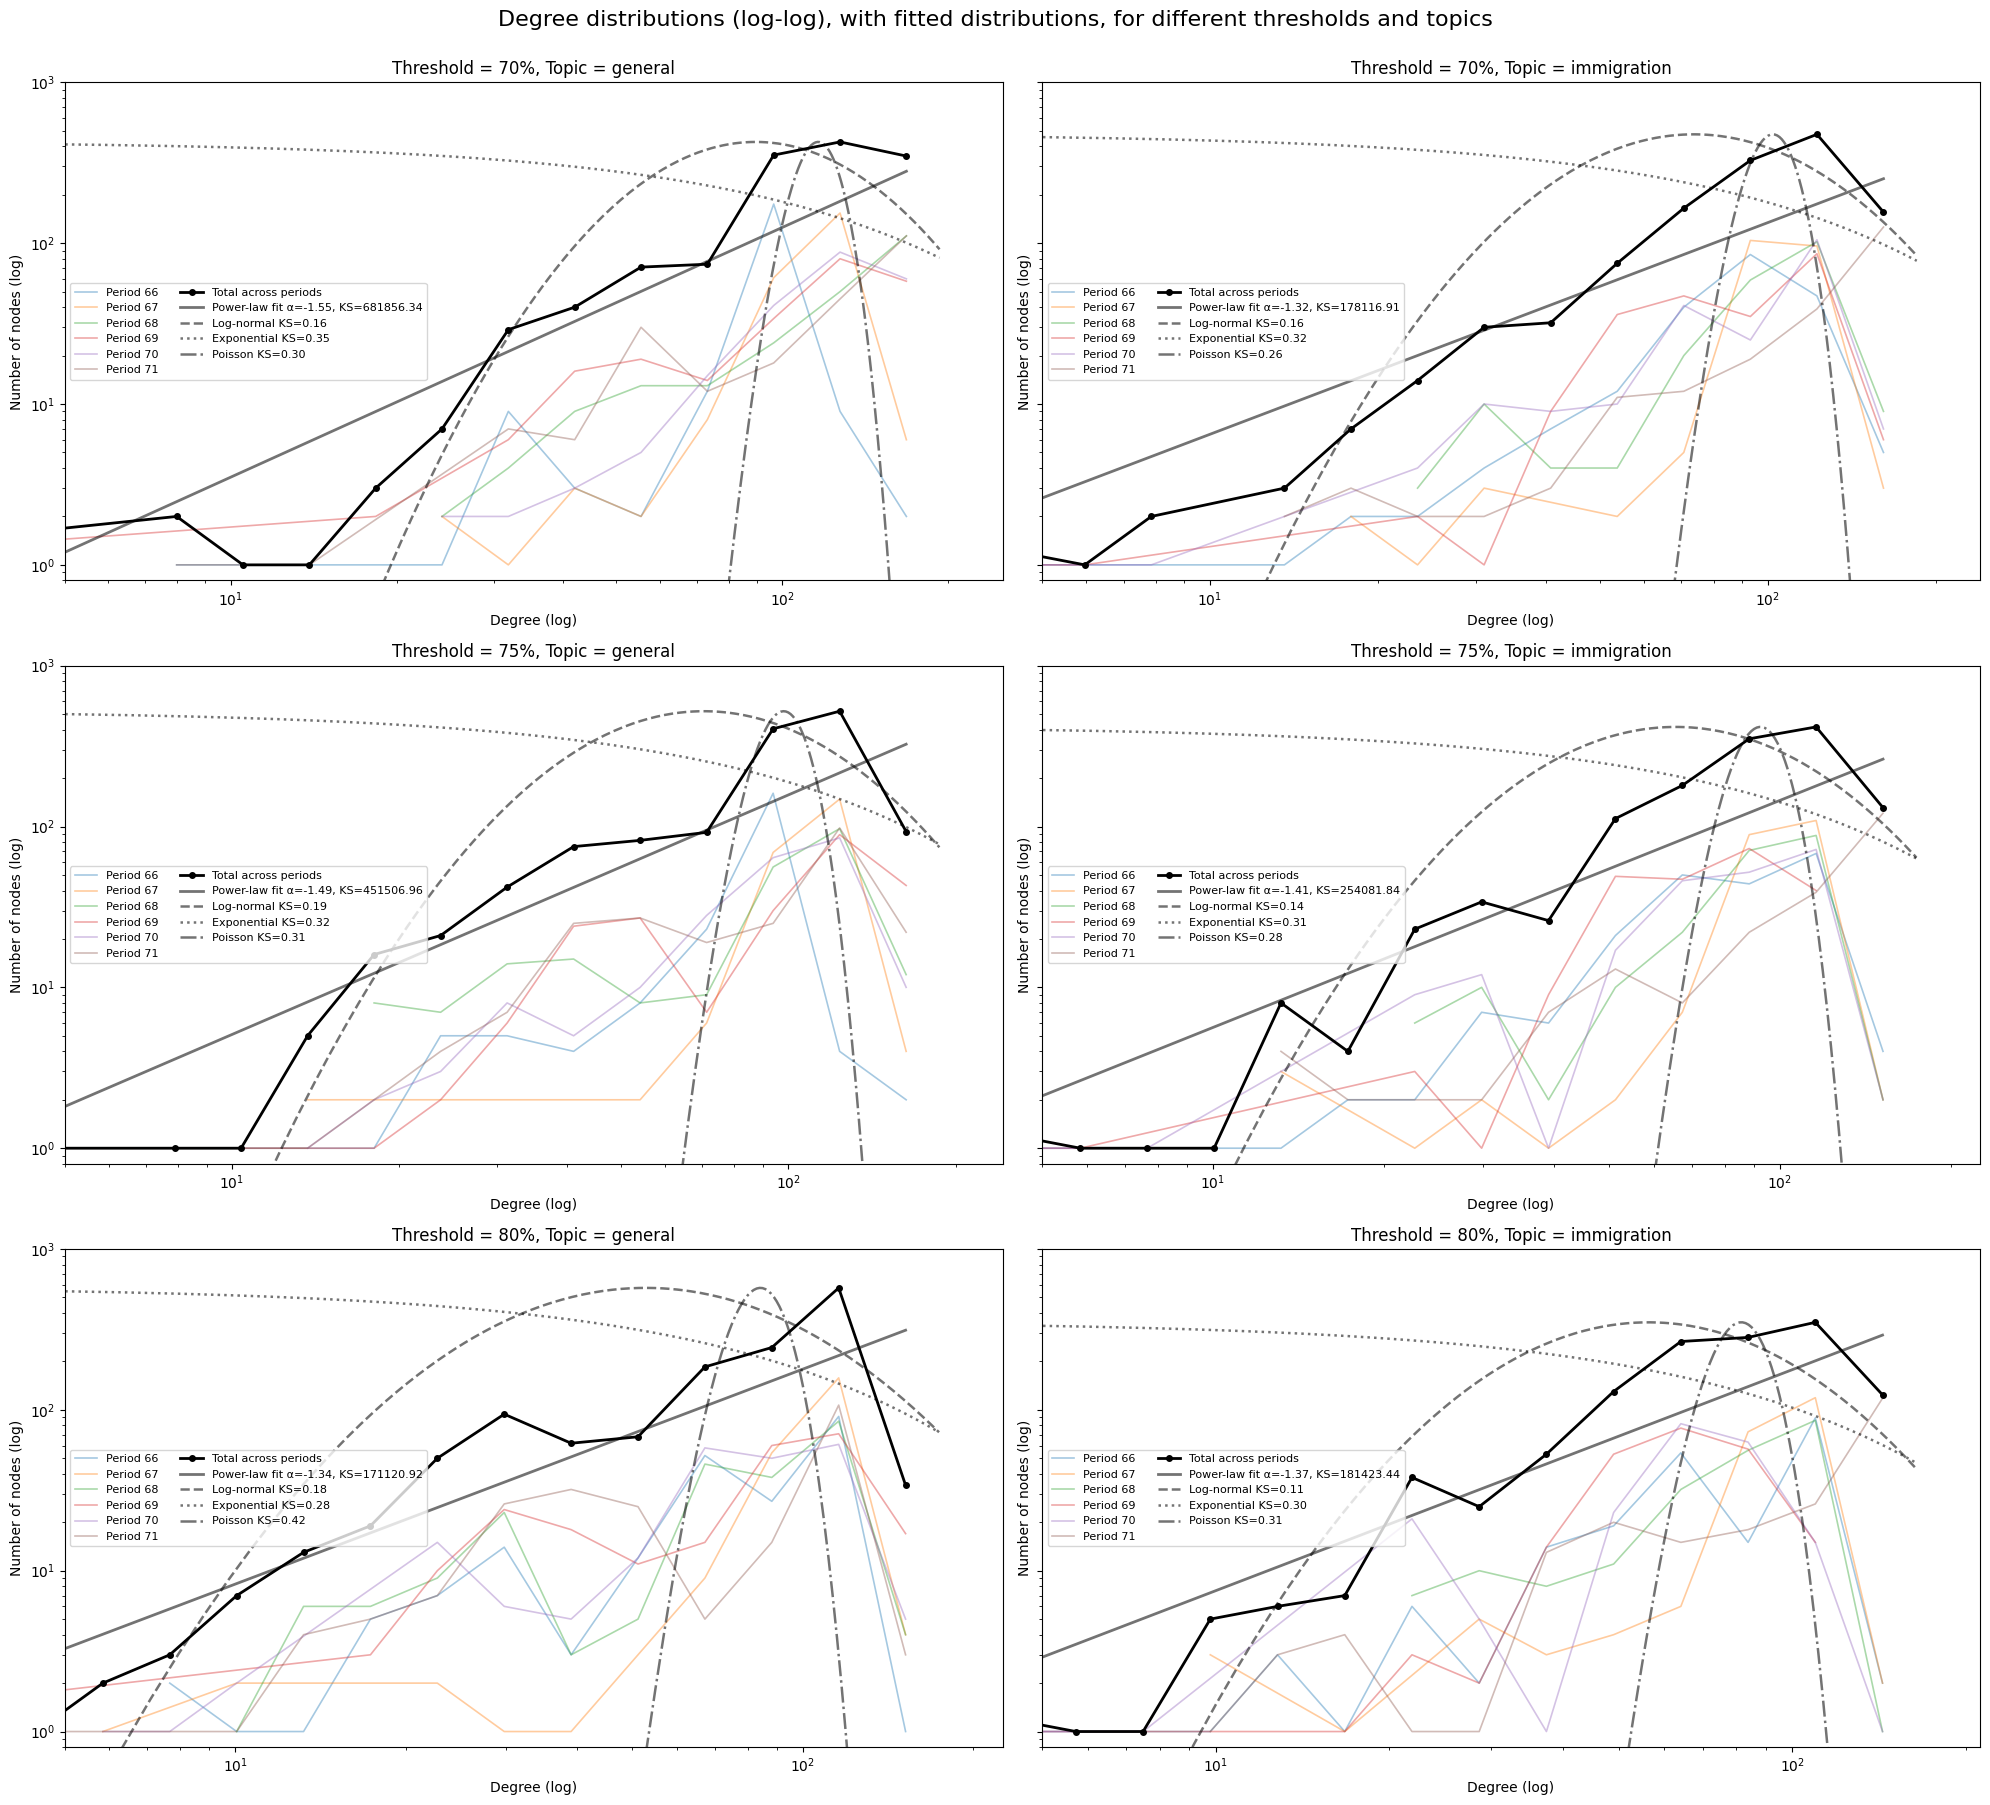

In [48]:
selected_topic = "general"
other_topic = "immigration"
df_deg_gen_70 = degrees_across_periods(topic=selected_topic, threshold=0.7)
df_deg_gen_75 = degrees_across_periods(topic=selected_topic, threshold=0.75)
df_deg_gen_80 = degrees_across_periods(topic=selected_topic, threshold=0.8)
df_deg_other_70 = degrees_across_periods(topic=other_topic, threshold=0.7)
df_deg_other_75 = degrees_across_periods(topic=other_topic, threshold=0.75)
df_deg_other_80 = degrees_across_periods(topic=other_topic, threshold=0.8)

fig, axs = plt.subplots(3, 2, figsize=(20, 18), sharey=True)
plt.suptitle(f"Degree distributions (log-log), with fitted distributions, for different thresholds and topics", fontsize = 16, y = 1.0)
periods = (66,67,68,69,70,71)
n_bins = 20

fit_and_plot_logbinned_multi(df_deg_gen_70, periods=periods, num_bins=n_bins, ax = axs[0,0], threshold=0.70, topic = selected_topic)
fit_and_plot_logbinned_multi(df_deg_gen_75, periods=periods, num_bins=n_bins, ax = axs[1,0], threshold=0.75, topic = selected_topic)
fit_and_plot_logbinned_multi(df_deg_gen_80, periods=periods, num_bins=n_bins, ax = axs[2,0], threshold=0.80, topic = selected_topic)

fit_and_plot_logbinned_multi(df_deg_other_70, periods=periods, num_bins=n_bins, ax = axs[0,1], threshold=0.70, topic = other_topic)
fit_and_plot_logbinned_multi(df_deg_other_75, periods=periods, num_bins=n_bins, ax = axs[1,1], threshold=0.75, topic = other_topic)
fit_and_plot_logbinned_multi(df_deg_other_80, periods=periods, num_bins=n_bins, ax = axs[2,1], threshold=0.80, topic = other_topic)


plt.tight_layout()
plt.show()


>**Figure X:** The plot shows the distributions of the degrees of the Politician Agreement Network across all periods, for all-votes "general" and for "immigration", aross 3 different thresholding values. It is compared to the PDF of 4 different distributions, a Power-law Distribution, a Log-Normal Distribution, an Exponential Distribution and a Poisson Distribution. The log-normal distribution consistently provides the best fit.

## Semantic Understanding
As concluded by the graph above, the best thresholding fit, depends on the topic. Across all topics it is however a threshold of 70% (lower threshold were tested and provided worse fits), that fits best, and it is therefore the threshold we will use going forward. But first we try and get a semantic understanding of the implications of thresholding.  
We attempt to understand the implications of thresholding, specifically from the perspective of the network being a Temporal Network. For the following analysis, we visualize the party agreement on a selected topic, across time periods.

In [7]:
def get_df_for_traditional_parties():
    party_edges = pd.read_csv(from_github(f"/edges/party/all_party_edges_by_Period.csv"))
    traditional_parties = ["Det Konservative Folkeparti", "Enhedslisten", "Liberal Alliance", "Radikale Venstre", "Socialdemokratiet", "Socialistisk Folkeparti", "Venstre", "Dansk Folkeparti"]
    trad_parties = (party_edges['source'].isin(traditional_parties) & party_edges['target'].isin(traditional_parties))
    df_trad = party_edges[trad_parties]
    return df_trad

df_traditional_parties = get_df_for_traditional_parties()

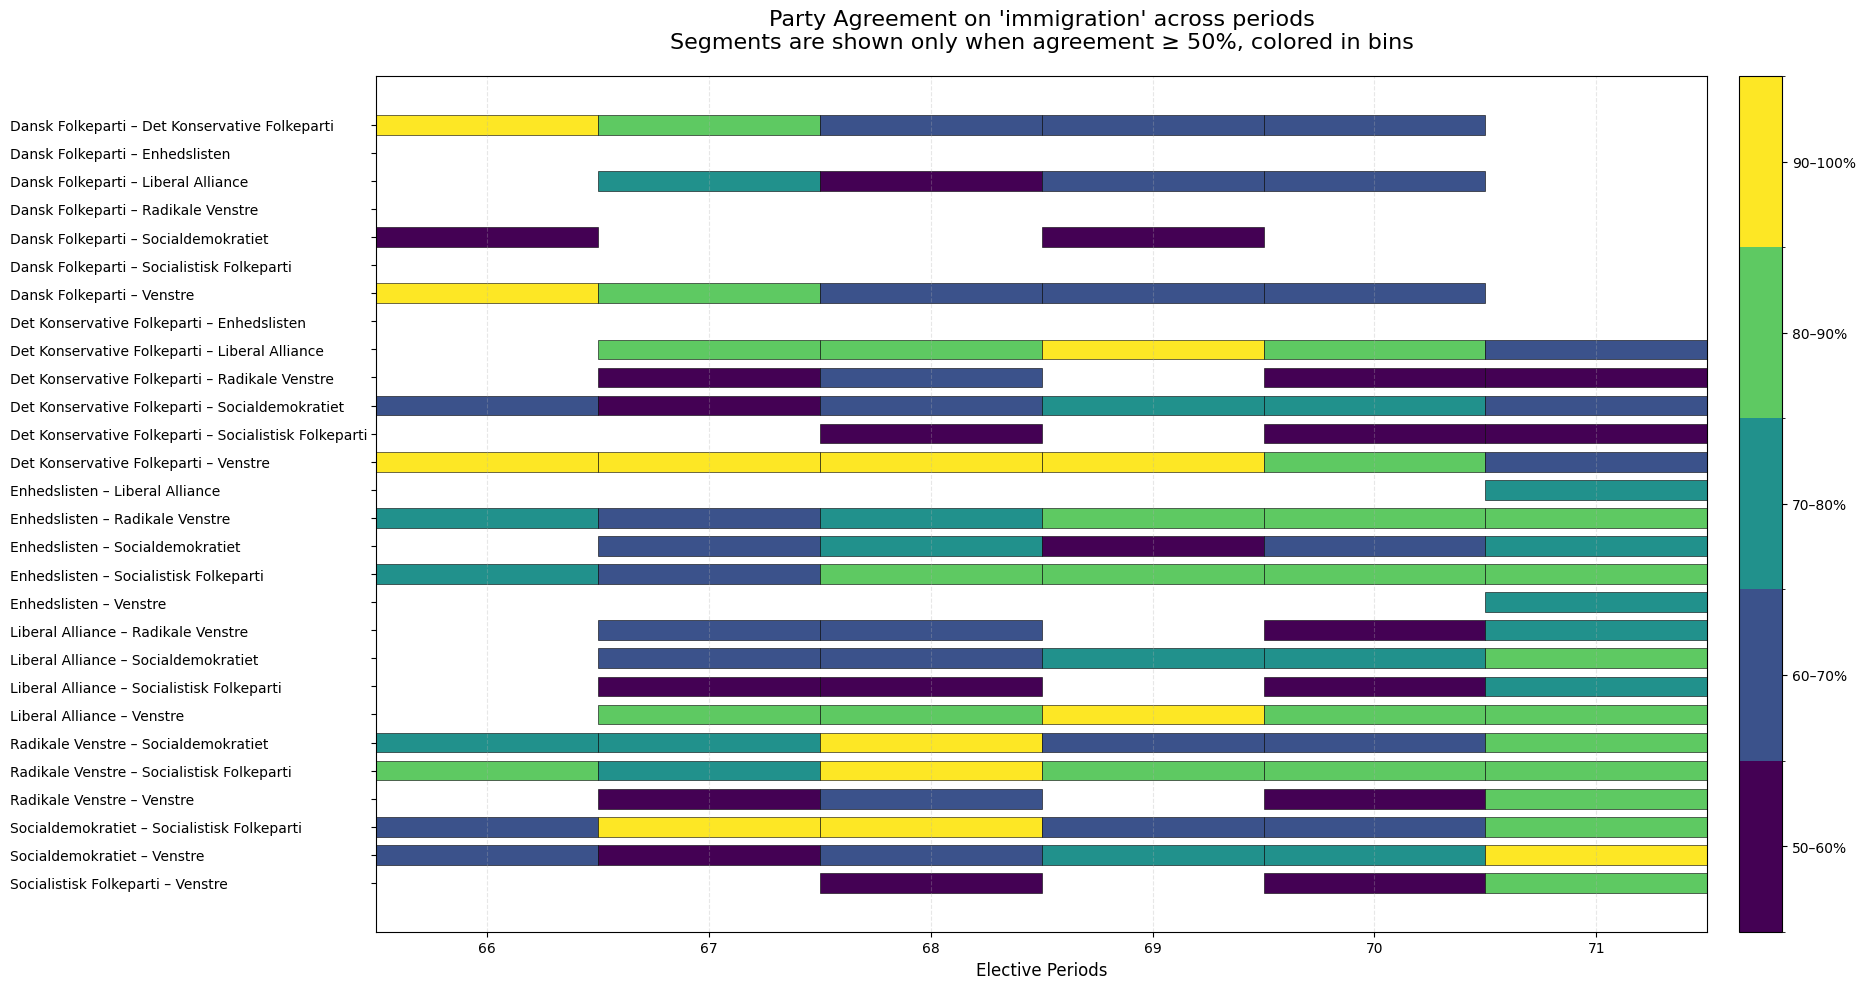

In [11]:
def plot_edge_timeline(
    df_trad,
    topic,
    weight_threshold=0.5,               # keep param; function enforces >= 0.5
    periods=(66, 67, 68, 69, 70, 71),
    cmap_name="viridis"
):
    df = df_trad.copy()

    # --- 1) Base filter: topic, periods, no self-edges ---
    base = df[
        (df["topic"] == topic) &
        (df["source"] != df["target"]) &
        (df["Period"].isin(periods))
    ].copy()

    if base.empty:
        print("No edges for this topic/period selection.")
        return

    # --- 2) Build edge label & sort for stable ordering ---
    base["edge"] = base["source"] + " – " + base["target"]
    base = base.sort_values(["source", "target"], ascending=False)

    edges = (base["source"] + " – " + base["target"]).unique().tolist()
    y_positions = {edge: i for i, edge in enumerate(edges)}

    # --- 3) Enforce 50% cutoff for drawing ---
    seg = base[base["weight"] >= 0.5].copy()

    # --- 4) Discrete bins & robust colormap setup (works on any MPL) ---
    bins = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0000001]  # include 1.0 in last bin
    base_cmap = plt.get_cmap(cmap_name)
    try:
        cmap = base_cmap.resampled(5)
    except AttributeError:
        # older MPL: make a 5-color ListedColormap
        cmap = colors.ListedColormap(base_cmap(np.linspace(0, 1, 5)))
    norm = colors.BoundaryNorm(bins, cmap.N)


    # --- 5) Plot ---
    fig, ax = plt.subplots(figsize=(20, 10))

    #COLOR STUFF
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02, boundaries=bins)
    cbar.set_ticks([0.55, 0.65, 0.75, 0.85, 0.95])
    cbar.set_ticklabels(["50–60%", "60–70%", "70–80%", "80–90%", "90–100%"])

    if not seg.empty:
        for _, row in seg.sort_values(["edge", "Period"]).iterrows():
            edge = row["edge"]
            period = row["Period"]
            weight = row["weight"]
            y = y_positions[edge]

            ax.broken_barh(
                [(period - 0.5, 1.0)],
                (y - 0.35, 0.7),
                facecolors=cmap(norm(weight)),
                edgecolors="black",
                linewidth=0.4
            )

    # --- 6) Axis formatting ---
    ax.set_yticks(range(len(edges)))
    ax.set_yticklabels(edges, ha="left")  # left align labels
    ax.tick_params(axis='y', pad=260)

    ax.set_xticks(list(periods))
    ax.set_xlim(min(periods) - 0.5, max(periods) + 0.5)

    ax.set_xlabel("Elective Periods", fontsize=12)

    # title_suffix = "" if not seg.empty else " (no weights ≥ 50% to display)"
    ax.set_title(
        f"Party Agreement on '{topic}' across periods\n"
        "Segments are shown only when agreement ≥ 50%, colored in bins",
        fontsize=16,
        pad=20
    )

    ax.grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_edge_timeline(df_traditional_parties, topic="immigration", weight_threshold=0.5)

>**Figure X:** The plot shows in which periods, party-pairs have had an agreement above 50%, and what interval their agreement lies in. In terms of Network Analysis the existance of an agreement above a certain threshold is interpreted as the duration in which nodes are connected. "Enhedslisten" has only in period 71 had an agreement above 50% regarding immigration with "Liberal Alliance", but they have had more than 50% agreement for all periods with both "Radikale Venstre" and "Socialistisk Folkeparti"

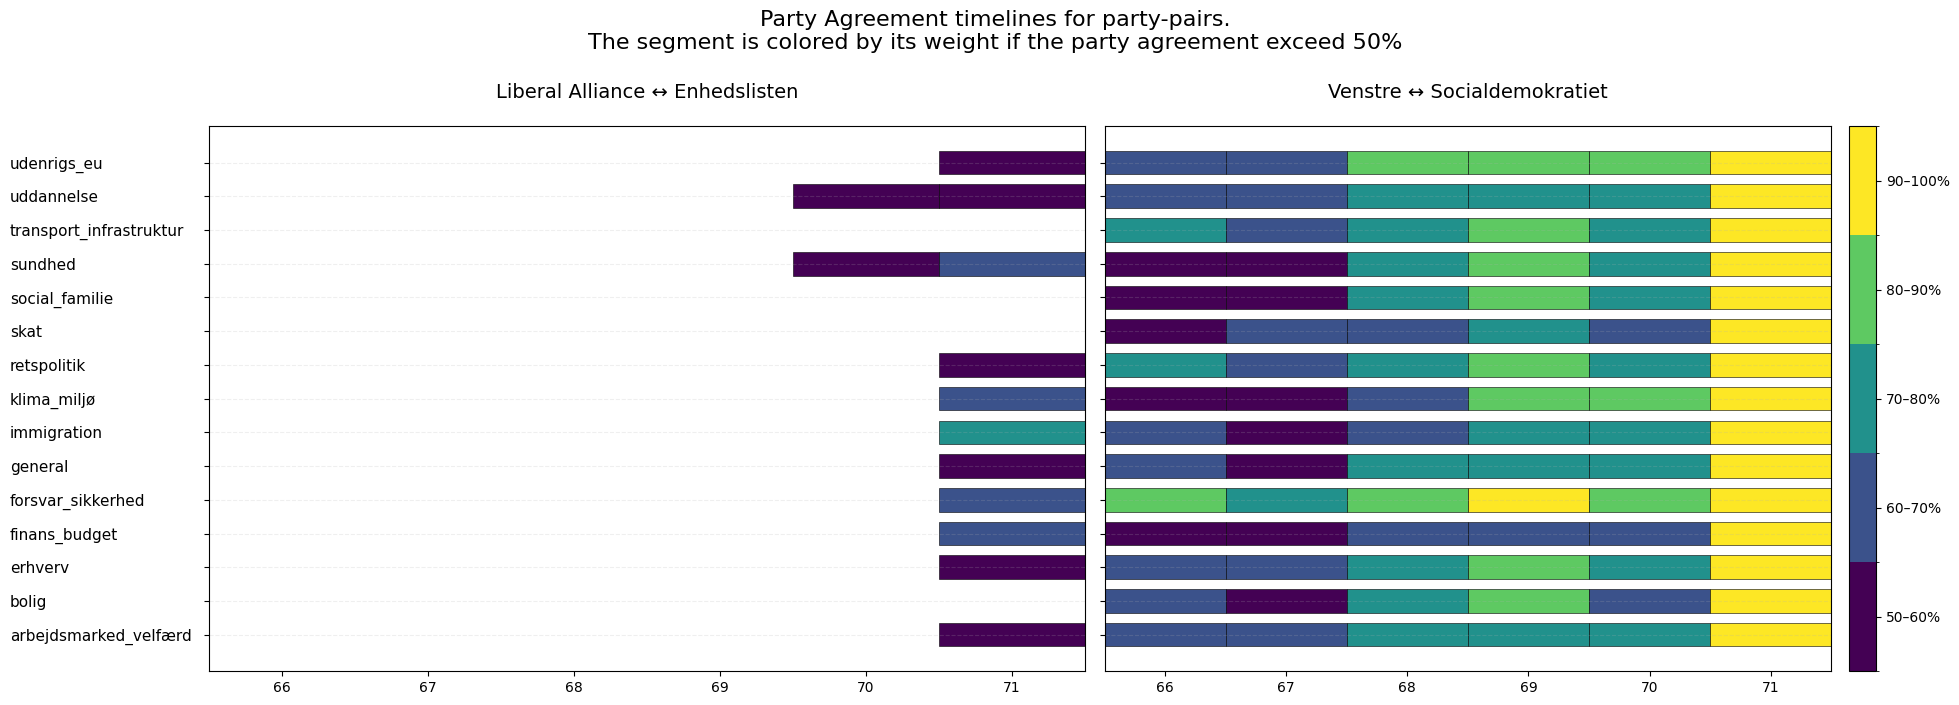

In [50]:
def plot_topic_timeline_for_pair(
    df_trad,
    party_a,
    party_b,
    weight_threshold=0.5,
    periods=(66, 67, 68, 69, 70, 71),
    cmap_name="viridis",
    ax=None,
    add_colorbar=False,
):
    df = df_trad.copy()
    parties = {party_a, party_b}

    # --- 1) Filter relevant edges --------------------------------------
    base = df[
        (df["source"].isin(parties)) &
        (df["target"].isin(parties)) &
        (df["source"] != df["target"]) &
        (df["Period"].isin(periods))
    ].copy()

    if base.empty:
        if ax is not None:
            ax.set_title(f"No data for {party_a} ↔ {party_b}")
        else:
            print("No edges for this party pair / period selection.")
        return ax

    # --- 2) Normalize direction so A–B and B–A combine ------------------
    base["src_norm"] = base[["source", "target"]].min(axis=1)
    base["tgt_norm"] = base[["source", "target"]].max(axis=1)

    # Aggregate weights per (topic, period)
    agg = (
        base
        .groupby(["topic", "Period", "src_norm", "tgt_norm"], as_index=False)
        .agg(weight=("weight", "mean"))
    )

    # --- 3) Topic positions -------------------------------------------
    topics = sorted(agg["topic"].unique())
    y_positions = {t: i for i, t in enumerate(topics)}

    # --- 4) Enforce 50% cutoff ----------------------------------------
    seg = agg[agg["weight"] >= 0.5].copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 10))

    if seg.empty:
        ax.set_yticks(range(len(topics)))
        ax.set_yticklabels(topics, ha="left", fontsize=11)
        ax.tick_params(axis='y', pad=120)
        ax.set_xticks(list(periods))
        ax.set_xlim(min(periods) - 0.5, max(periods) + 0.5)
        ax.set_xlabel("Elective Periods", fontsize=12)
        ax.set_title(f"{party_a} ↔ {party_b}\nNo weights ≥ 50%", fontsize=14, pad=20)
        ax.grid(axis="y", linestyle="--", alpha=0.2)
        return ax

    # --- 5) Discrete color bins ---------------------------------------
    bins = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0000001]
    cmap = plt.get_cmap(cmap_name, 5)  # works on older Matplotlib
    norm = colors.BoundaryNorm(bins, cmap.N)

    # --- 6) Draw bars --------------------------------------------------
    for _, row in seg.sort_values(["topic", "Period"]).iterrows():
        topic = row["topic"]
        period = row["Period"]
        weight = row["weight"]
        y = y_positions[topic]

        ax.broken_barh(
            [(period - 0.5, 1.0)],
            (y - 0.35, 0.7),
            facecolors=cmap(norm(weight)),
            edgecolors="black",
            linewidth=0.4,
        )

    # --- 7) Axis formatting -------------------------------------------
    ax.set_yticks(range(len(topics)))
    ax.set_yticklabels(topics, ha="left", fontsize=11)
    ax.tick_params(axis='y', pad=140)
    ax.set_xticks(list(periods))
    ax.set_xlim(min(periods) - 0.5, max(periods) + 0.5)
    ax.set_title(f"{party_a} ↔ {party_b}", fontsize=14, pad=20)
    ax.grid(axis="y", linestyle="--", alpha=0.2)

    # --- 8) Optional colorbar -----------------------------------------
    if add_colorbar:
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.02, boundaries=bins)
        cbar.set_ticks([0.55, 0.65, 0.75, 0.85, 0.95])
        cbar.set_ticklabels(["50–60%", "60–70%", "70–80%", "80–90%", "90–100%"])
        # cbar.set_label("Agreement weight (binned)", fontsize=12)

    return ax

fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

plot_topic_timeline_for_pair(df_traditional_parties, "Liberal Alliance", "Enhedslisten", ax=axs[0])
plot_topic_timeline_for_pair(df_traditional_parties, "Venstre", "Socialdemokratiet", ax=axs[1], add_colorbar=True)

plt.suptitle("Party Agreement timelines for party-pairs.\nThe segment is colored by its weight if the party agreement exceed 50%", fontsize=16, y=1)
plt.tight_layout()
plt.show()


>**Figure X:** The plot shows two party pairs, and what topics they have had an agreement on (edge between) for different periods. Period 71 seems to be a period of extremely high agreement, where "Venstre" and "Socialdemokratiet" have extremely high agreement across all legislation. This makes sense as they are 2 of the 3 parties in government.

Our analysis shows that the connection between edges is very dependent on the topic, and the thresholding value. The connections can concluded to likely also relate to communities, as the first graph showed that "Enhedslisten" always agrees with "Radikale Venstre" and "Socialistisk Folkeparti", which can be attributed to their belonging to "rød blok", whilst "Venstre" and "Socialdemokratiet" are different "blocs" but have extremely high agreement in a period where they are in government together.